Found 5 file(s) (in plot order):
  1C.xlsx                                       → rate: 1C
  2C.xlsx                                       → rate: 2C
  5C.xlsx                                       → rate: 5C
  20C.xlsx                                      → rate: 20C
  1C-fnl.xlsx                                   → rate: 1C
Saved: all_rates_cycle2_Q-E.png


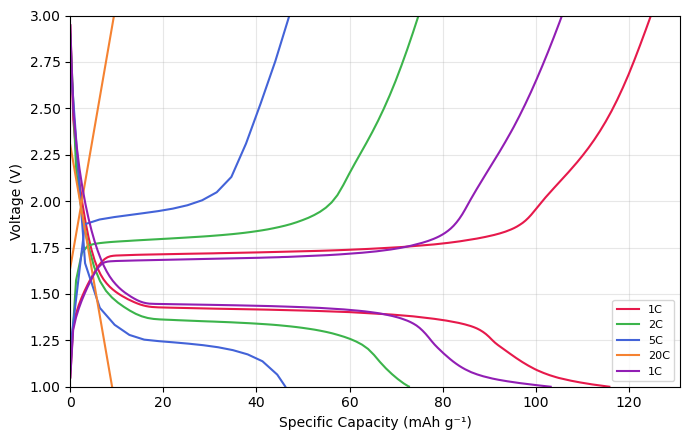

In [15]:
"""
Battery Rate Test Plotter
=========================
Reads multiple Excel files (one per C-rate), each containing 3 charge/discharge cycles.
Supports 4 plot types and 2 display modes.

Excel column format expected:
  - 'time/s'   : time in seconds
  - '<I>/mA'   : current in mA
  - 'Ewe/V'    : voltage in V

Each half-cycle (charge or discharge) is detected by current sign change.
"""

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap

# ─────────────────────────────────────────────────────────────────────────────
# USER CONFIG — edit here
# ─────────────────────────────────────────────────────────────────────────────

# Folder containing the Excel files (use '.' for current directory)
DATA_FOLDER = "."

RATE_MAP = {
    "1C.xlsx": "1C",
    "2C.xlsx": "2C",
    "5C.xlsx": "5C",
    "10.xlsx":   "10C",
    "20C.xlsx":   "20C",
    "1C-fnl.xlsx":   "1C",
}


# Plot type: 'V-t' | 'I-t' | 'Q-E' | 'dQdV-V'
PLOT_TYPE = "Q-E"

# Display mode:
#   'all'  → one figure per rate, showing all 3 cycles
#   'nth'  → one figure, each rate's N-th cycle overlaid
DISPLAY_MODE = "nth"
V_LIM = [1.0, 3]  # or None
COLORS = None
# Which cycle to plot when DISPLAY_MODE == 'nth'  (1-indexed)
NTH_CYCLE = 2

# Active mass per electrode in mg (set to None to use raw mAh instead of mAh/g)
ACTIVE_MASS_MG = 0.185   # e.g. 2.5

# Whether to plot only discharge half-cycles in Q-E and dQ/dV plots
DISCHARGE_ONLY = False

# ─────────────────────────────────────────────────────────────────────────────


# ── helpers ──────────────────────────────────────────────────────────────────

def load_file(path: str) -> pd.DataFrame:
    """
    Read a BioLogic-exported Excel file.

    BioLogic often exports two column-pairs side by side:
      Col A: time/s   Col B: <I>/mA   Col C: time/s   Col D: Ewe/V
    pandas renames the duplicate 'time/s' to 'time/s.1', so we need to
    detect and handle this layout explicitly.
    """
    raw = pd.read_excel(path, header=None, dtype=str)

    # ── find the header row (first row containing 'time/s') ──────────────────
    header_row = None
    for i, row in raw.iterrows():
        if any("time/s" in str(c).lower() for c in row.values):
            header_row = i
            break
    if header_row is None:
        raise ValueError(f"Cannot find header row with 'time/s' in {path}")

    df = pd.read_excel(path, header=header_row)
    df.columns = [str(c).strip() for c in df.columns]

    # ── debug: print columns so user can see what was parsed ─────────────────
    # Uncomment the next line if you need to diagnose column issues:
    # print(f"  Columns in {os.path.basename(path)}: {df.columns.tolist()}")

    # ── handle side-by-side duplicate layout ─────────────────────────────────
    # BioLogic puts (time/s, <I>/mA) in cols 0-1 and (time/s, Ewe/V) in cols 2-3.
    # After pd.read_excel the duplicate 'time/s' becomes 'time/s.1'.
    cols = df.columns.tolist()

    # Build a unified DataFrame with exactly the three columns we need.
    # Strategy: scan all columns for best match to each required name.
    def find_col(candidates):
        """Return first column name that contains any of the candidate strings."""
        for candidate in candidates:
            for c in cols:
                if candidate.lower() in c.lower():
                    return c
        return None

    col_t = find_col(["time/s"])
    col_i = find_col(["<i>/ma", "i>/ma", "/ma"])
    col_v = find_col(["ewe/v", "we/v", "/v"])

    missing = [name for name, col in [("time/s", col_t), ("<I>/mA", col_i), ("Ewe/V", col_v)] if col is None]
    if missing:
        msg = (f"Could not find columns {missing} in {os.path.basename(path)}. "
               f"Available columns: {cols}. "
               f"Tip: check the file and update find_col() search strings in load_file().")
        raise KeyError(msg)

    out = pd.DataFrame({
        "time/s":  df[col_t],
        "<I>/mA":  df[col_i],
        "Ewe/V":   df[col_v],
    })

    # ── keep only numeric rows ────────────────────────────────────────────────
    for col in ["time/s", "<I>/mA", "Ewe/V"]:
        out[col] = pd.to_numeric(out[col], errors="coerce")

    out = out.dropna(subset=["time/s", "<I>/mA", "Ewe/V"]).reset_index(drop=True)
    return out


def split_cycles(df: pd.DataFrame):
    """
    Split DataFrame into cycles (list of DataFrames).
    A new cycle starts each time current changes from non-zero to positive
    (beginning of a charge step) after a rest/discharge.
    Returns list of (charge_df, discharge_df) tuples.
    """
    # label each row: 1=charge, -1=discharge, 0=rest
    sign = np.sign(df["<I>/mA"].values)
    # find indices where a new 'charge' segment starts
    cycles = []
    in_cycle = False
    seg_start = 0

    # simple approach: detect sign-change boundaries and group into full cycles
    boundaries = [0]
    for k in range(1, len(sign)):
        if sign[k] != sign[k - 1]:
            boundaries.append(k)
    boundaries.append(len(sign))

    segments = []
    for a, b in zip(boundaries[:-1], boundaries[1:]):
        seg = df.iloc[a:b].copy()
        seg_sign = sign[a]
        segments.append((seg_sign, seg))

    # group segments into cycles: charge(+) then discharge(-)
    i = 0
    while i < len(segments):
        s, seg = segments[i]
        if s == 1:  # charge
            chg = seg
            dis = None
            if i + 1 < len(segments) and segments[i + 1][0] == -1:
                dis = segments[i + 1][1]
                i += 2
            else:
                i += 1
            cycles.append((chg, dis))
        elif s == -1:  # discharge first (no preceding charge)
            cycles.append((None, seg))
            i += 1
        else:  # rest
            i += 1

    return cycles


def compute_capacity(seg: pd.DataFrame):
    """Return cumulative capacity array (mAh) and energy (mWh) for a segment."""
    t = seg["time/s"].values
    I = seg["<I>/mA"].values   # mA
    V = seg["Ewe/V"].values

    dt = np.diff(t, prepend=t[0])
    dQ = np.abs(I) * dt / 3600  # mAh increments
    Q = np.cumsum(dQ)
    E = np.cumsum(np.abs(I) * V * dt / 3600)  # mWh
    return Q, E, V


def dqdv(Q, V, n_points=500):
    """Smooth dQ/dV vs V using a sliding window."""
    # sort by V
    idx = np.argsort(V)
    Vs = V[idx]
    Qs = Q[idx]
    # remove duplicate V values
    _, ui = np.unique(Vs, return_index=True)
    Vs, Qs = Vs[ui], Qs[ui]
    if len(Vs) < 5:
        return Vs, np.zeros_like(Vs)
    dQ = np.gradient(Qs, Vs)
    # interpolate onto uniform grid and smooth
    V_grid = np.linspace(Vs[0], Vs[-1], n_points)
    dQ_interp = np.interp(V_grid, Vs, dQ)
    # Gaussian smooth
    from scipy.ndimage import gaussian_filter1d
    dQ_smooth = gaussian_filter1d(dQ_interp, sigma=5)
    return V_grid, dQ_smooth


def rate_label(filepath: str) -> str:
    """
    Return rate label for a file.
    Priority: RATE_MAP lookup -> regex from filename -> filename stem.
    """
    import re
    basename = os.path.basename(filepath)
    if basename in RATE_MAP:
        return RATE_MAP[basename]
    m = re.search(r"(\d+[_.]?\d*)\s*[Cc]", basename)
    if m:
        return m.group(0).replace("_", ".")
    return os.path.splitext(basename)[0]


def get_ordered_files(all_files: list) -> list:
    """Return only the files listed in RATE_MAP, in RATE_MAP order."""
    by_base = {os.path.basename(f): f for f in all_files}
    return [by_base[b] for b in RATE_MAP if b in by_base]


# ── plot functions ────────────────────────────────────────────────────────────

def plot_segment(ax, seg, cycle_idx, color, label, plot_type, t_offset=0):
    t = seg["time/s"].values
    I = seg["<I>/mA"].values
    V = seg["Ewe/V"].values

    if plot_type == "V-t":
        ax.plot((t - t[0] + t_offset) / 3600, V, color=color, label=label)
        ax.set_xlabel("Time (h)")
        ax.set_ylabel("Voltage (V)")

    elif plot_type == "I-t":
        ax.plot((t - t[0] + t_offset) / 3600, I, color=color, label=label)
        ax.set_xlabel("Time (h)")
        ax.set_ylabel("Current (mA)")

    elif plot_type == "Q-E":
        Q, E, _ = compute_capacity(seg)
        if ACTIVE_MASS_MG:
            Q = Q / ACTIVE_MASS_MG * 1000  # mAh/g
            ylabel = "Specific Capacity (mAh g⁻¹)"
        else:
            ylabel = "Capacity (mAh)"
        ax.plot(Q, V, color=color, label=label)
        ax.set_xlabel(ylabel)
        ax.set_ylabel("Voltage (V)")

    elif plot_type == "dQdV-V":
        Q, _, V_arr = compute_capacity(seg)
        try:
            V_g, dQ_g = dqdv(Q, V_arr)
            ax.plot(V_g, dQ_g, color=color, label=label)
        except Exception:
            pass
        ax.set_xlabel("Voltage (V)")
        unit = "mAh g⁻¹ V⁻¹" if ACTIVE_MASS_MG else "mAh V⁻¹"
        ax.set_ylabel(f"dQ/dV ({unit})")
    if V_LIM is not None:
        if plot_type in ("V-t", "Q-E"):
            ax.set_ylim(V_LIM)
        elif plot_type == "dQdV-V":
            ax.set_xlim(V_LIM)
    ax.set_xlim(left=0)


def make_figure_title(plot_type, mode_info):
    titles = {"V-t": "Voltage vs Time", "I-t": "Current vs Time",
              "Q-E": "Voltage vs Capacity", "dQdV-V": "dQ/dV vs Voltage"}
    return f"{titles[plot_type]} — {mode_info}"


# ── main ──────────────────────────────────────────────────────────────────────

def main():
    all_files = sorted(glob.glob(os.path.join(DATA_FOLDER, "*.xlsx")) +
                        glob.glob(os.path.join(DATA_FOLDER, "*.xls")))
    if not all_files:
        raise FileNotFoundError(f"No Excel files found in '{DATA_FOLDER}'")

    files = get_ordered_files(all_files)

    print(f"Found {len(files)} file(s) (in plot order):")
    for f in files:
        print(f"  {os.path.basename(f):45s} → rate: {rate_label(f)}")

    # Use visually distinct colors easy to tell apart
    distinct_colors = [
        "#e6194b",  # red
        "#3cb44b",  # green
        "#4363d8",  # blue
        "#f58231",  # orange
        "#911eb4",  # purple
        "#42d4f4",  # cyan
        "#f032e6",  # magenta
        "#bfef45",  # lime
        "#fabed4",  # pink
        "#469990",  # teal
    ]
    _palette = COLORS if COLORS else ["#e6194b","#3cb44b","#4363d8","#f58231","#911eb4","#42d4f4"]
    def get_color(idx):
        return _palette[idx % len(_palette)]
    # ── MODE: all ─────────────────────────────────────────────────────────────
    if DISPLAY_MODE == "all":
        for file_idx, fpath in enumerate(files):
            df = load_file(fpath)
            cycles = split_cycles(df)
            rate = rate_label(fpath)

            fig, ax = plt.subplots(figsize=(7, 4.5))
            #fig.suptitle(make_figure_title(PLOT_TYPE, f""))

            for c_idx, (chg, dis) in enumerate(cycles):
                color = get_color(c_idx)
                labeled = False
                t_offset = 0
                if not DISCHARGE_ONLY and chg is not None:
                    lbl = f"Cycle {c_idx + 1}" if not labeled else "_"
                    labeled = True
                    plot_segment(ax, chg, c_idx, color, lbl, PLOT_TYPE, t_offset)
                    t_offset += chg["time/s"].values[-1] - chg["time/s"].values[0]
                if dis is not None:
                    lbl = f"Cycle {c_idx + 1}" if not labeled else "_"
                    labeled = True
                    plot_segment(ax, dis, c_idx, color, lbl, PLOT_TYPE, t_offset)

            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)
            fig.tight_layout()
            out_name = f"rate_{rate}_{PLOT_TYPE.replace('/', '_')}_all_cycles.png"
            fig.savefig(out_name, dpi=150)
            print(f"Saved: {out_name}")

    # ── MODE: nth ─────────────────────────────────────────────────────────────
    elif DISPLAY_MODE == "nth":
        fig, ax = plt.subplots(figsize=(7, 4.5))
        #fig.suptitle(make_figure_title(PLOT_TYPE, f""))

        for file_idx, fpath in enumerate(files):
            df = load_file(fpath)
            cycles = split_cycles(df)
            rate = rate_label(fpath)
            color = get_color(file_idx)

            if NTH_CYCLE > len(cycles):
                print(f"  ⚠ {rate}: only {len(cycles)} cycle(s), skipping cycle {NTH_CYCLE}")
                continue

            chg, dis = cycles[NTH_CYCLE - 1]

            labeled = False
            t_offset = 0
            if not DISCHARGE_ONLY and chg is not None:
                plot_segment(ax, chg, NTH_CYCLE - 1, color, rate, PLOT_TYPE, t_offset)
                labeled = True
                t_offset += chg["time/s"].values[-1] - chg["time/s"].values[0]
            if dis is not None:
                lbl = "_" if labeled else rate
                plot_segment(ax, dis, NTH_CYCLE - 1, color, lbl, PLOT_TYPE, t_offset)

        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        fig.tight_layout()
        out_name = f"all_rates_cycle{NTH_CYCLE}_{PLOT_TYPE.replace('/', '_')}.png"
        fig.savefig(out_name, dpi=150)
        print(f"Saved: {out_name}")

    else:
        raise ValueError(f"Unknown DISPLAY_MODE: '{DISPLAY_MODE}'. Use 'all' or 'nth'.")

    plt.show()


if __name__ == "__main__":
    main()